# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** BAI Yongqi

**Date:** 2026/09/01

df.shape: (30478, 13) 

object
['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285'] 

Total missings: 0 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 



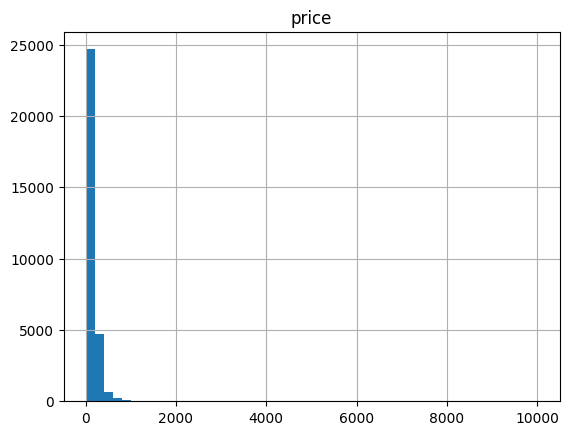

df.shape: (12925, 13) 

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Total missings: 9848
proportion missing: 0.762 

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    150  
Yes                         44    172   

force_type  Baton  Bodily Force  Chemical Irritant  Firearm  \
injury_nan                

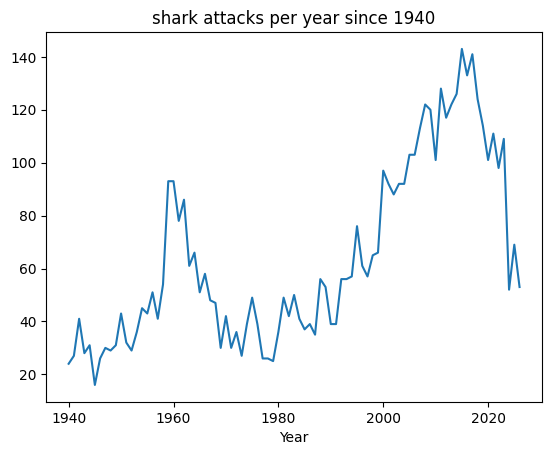

Year
1940     283
1950     467
1960     618
1970     339
1980     438
1990     572
2000    1022
2010    1249
2020     593
Name: count, dtype: int64 

Age
16    92
19    90
17    89
17    87
18    85
15    84
20    79
20    77
18    75
15    73
21    72
25    70
22    67
14    63
19    63
16    61
22    60
21    59
24    59
24    58
26    57
13    57
14    56
12    55
13    52
Name: count, dtype: int64 

Total missings: 3129 ( 0.44 )
count    3988.000000
mean       28.263039
std        14.699712
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64 



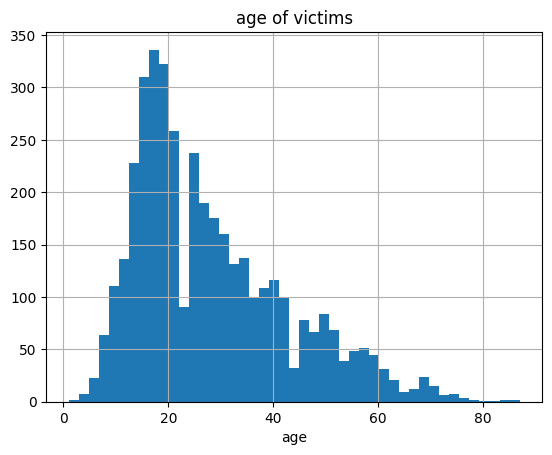

Sex
M        5704
F         816
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64 

Sex
M    5713
F     818
Name: count, dtype: int64 

Total missings: 586 

male: 5713 sex recorded: 6531
proportion male: 0.875 

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64 

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

proportion unprovoked: 0.739 



In [1]:
# Your Phase 1 solution to the problem goes here.
# ds3001 data wrangling hw
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Q1.1 airbnb price
df = pd.read_csv('./data/airbnb_hw.csv', low_memory=False)
print('df.shape:', df.shape, '\n')

var = 'Price'
print(df[var].dtype)
print(df[var].unique()[0:15], '\n')

# it's object not a number. looks like anything over 999 has a comma in it
# (1,990 / 5,000) so pandas can't read the column as numeric. take the comma
# out first like we did with the $ sign, then coerce.
df[var] = df[var].str.replace(',', '')
df[var] = pd.to_numeric(df[var], errors='coerce')
df['price_nan'] = df[var].isnull()

print('Total missings:', sum(df['price_nan']), '\n')
print(df[var].describe(), '\n')

df[var].hist(bins=50)
plt.title('price')
plt.show()

# Q1.1 answer: 0 missing. everything converts once the comma is gone.
# range is 10 to 10000, median 125, mean 164, so it's skewed right.
# i didn't fill or drop anything, price is a measured value and making
# some up would be a different kind of decision.


# Q1.2 mn police subject_injury
df = pd.read_csv('./data/mn_police_use_of_force.csv', low_memory=False)
print('df.shape:', df.shape, '\n')

var = 'subject_injury'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

# only Yes / No / blank in here, no weird codes like y or 1 to fix. so the
# real question is the NAs. leaving them as nan and keeping a flag, same as
# age_nan in the lecture. could recode them to No but that assumes officers
# only wrote it down when there was an injury, and nothing in the file says
# that.
df[var] = df[var].str.strip()
df[var] = df[var].replace(['', ' '], np.nan)
df['injury_nan'] = df[var].isnull()

print('Total missings:', sum(df['injury_nan']))
print('proportion missing:', df['injury_nan'].mean().round(3), '\n')

# the crosstab the question asks for
print(pd.crosstab(df[var], df['force_type']), '\n')

# and where the missing ones are
ct = pd.crosstab(df['injury_nan'], df['force_type'])
print(ct, '\n')
print('share missing by force type:')
print((ct.loc[True] / ct.sum()).round(3), '\n')

# two whole categories are 100% missing which seems weird, so checking if
# it's a time thing. year is just the first 4 characters of the timestamp.
df['year'] = df['response_datetime'].str[0:4]
print(pd.crosstab(df['injury_nan'], df['year']), '\n')

df['day'] = df['response_datetime'].str[0:10]
print('last record with a value:', df.loc[df['injury_nan'] == False, 'day'].max(), '\n')

df['old'] = df['day'] <= '2018/06/02'
print('rows up to then:', sum(df['old']),
      'missing:', df.loc[df['old'], 'injury_nan'].mean().round(3))
print('rows after:     ', sum(~df['old']),
      'missing:', df.loc[~df['old'], 'injury_nan'].mean().round(3), '\n')

ct2 = pd.crosstab(df.loc[df['old'], 'injury_nan'],
                  df.loc[df['old'], 'force_type'])
print(ct2, '\n')
print('share missing by force type, earlier period only:')
print((ct2.loc[True] / ct2.sum()).round(3), '\n')

# Q1.2 answer: 9848 of 12925 missing = 76.2%. yes it's a concern.
#
# only 3077 incidents have any injury value at all so anything you compute
# on the complete cases uses less than a quarter of the data. and the
# missing ones don't look like the ones we can see.
#
# the crosstab by year shows why. 2016 and 2017 are around 35-40% missing
# but 2019 2020 2021 are all exactly 1.00. the last record with any value
# is 2018/06/02, so after that the field just stopped being filled in.
# that's 7982 rows and about 81% of all the missing values. it also
# explains why Maximal Restraint Technique and Less Lethal were 100%
# missing, those categories only show up after the cutoff.
#
# in the earlier period it's still 38% missing and it depends on the force
# type. chemical irritant is 82% missing and when it does get recorded the
# answer is mostly No (131 No vs 41 Yes). taser is 5% missing and k9 bite
# is 0%, and both of those have high injury rates. bodily force is in the
# middle at 30%. pepper spray doesn't leave a mark so there's nothing to
# write down, a dog bite does.
#
# so injuries get recorded when you can see them, which means the missing
# ones are probably mostly non-injuries and the 53% injury rate you get
# from the complete cases is too high.

df.to_csv('mn_police_clean.csv', index=False)


#Q2.1 open the shark file
df = pd.read_excel('./data/GSAF5.xls')
print('df.shape:', df.shape, '\n')
print(df.dtypes, '\n')
df.head()


# Q2.2 drop empty columns
print(df.notnull().sum().sort_values(), '\n')

# Unnamed 21 and 22 have 1 and 2 values in them and that's it
print(df[['Unnamed: 21', 'Unnamed: 22']].dropna(how='all'), '\n')
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
df = df.rename(columns={'Species ': 'Species'})
print('df.shape:', df.shape, '\n')


#Q2.3 year
var = 'Year'
print(df[var].describe(), '\n')
print(df.loc[df[var] < 1900, var].value_counts().sort_index().head(), '\n')
print(df.loc[df[var] == 0, ['Date', 'Year', 'Country']].tail(), '\n')

# range is 0 to 2026. 2026 is fine but there are 129 rows with 0 and 0
# isn't a year. looking at their Date column they say things like
# "1845-1853" or "Before 1906", so 0 is being used for "don't know",
# same idea as the 9 and 99 codes in the pretrial data. recoding to nan.
df[var] = df[var].replace(0, np.nan)
df['year_nan'] = df[var].isnull()
print('Total missings:', sum(df['year_nan']))
print('range now:', df[var].min(), 'to', df[var].max(), '\n')

recent = df[df[var] >= 1940]
print('records since 1940:', recent.shape[0], '\n')

recent[var].value_counts().sort_index().plot()
plt.title('shark attacks per year since 1940')
plt.show()

decade = (recent[var] // 10 * 10).astype(int)
print(decade.value_counts().sort_index(), '\n')

# Q2.3 answer: increasing, at least until recently. 283 in the 1940s up to
# 1249 in the 2010s. the 2020s number is lower but that decade isn't
# finished yet so you can't compare it directly. the last couple of years
# in the plot drop off a lot which is probably just because recent cases
# haven't been verified and added yet.
#
# but this is counting recorded attacks, not the actual risk. way more
# people surf and swim now than in 1940 and reporting is much better, so
# some of the increase is that and not sharks.


#Q2.4 age
var = 'Age'
print(df[var].value_counts().head(25), '\n')

# object because of stuff like 30s, 20's, Teen, ?, 28 & 22, 18 months.
# taking off the s and the apostrophe gets the decade ones ('30s' -> 30),
# and coerce turns the rest into nan. i'm reading '30s' as 30 rather than
# 35, since 30 is actually in the cell and 35 would be me making up a
# number. the ones with two ages in them like '28 & 22' are really two
# victims in one row so i'm not trying to guess which one to keep.
df[var] = df[var].astype(str).str.strip()
df[var] = df[var].str.replace("'", '')
df[var] = df[var].str.replace('s', '')
df[var] = pd.to_numeric(df[var], errors='coerce')
df.loc[df[var] > 110, var] = np.nan
df['age_nan'] = df[var].isnull()

print('Total missings:', sum(df['age_nan']),
      '(', df['age_nan'].mean().round(3), ')')
print(df[var].describe(), '\n')

df[var].hist(bins=45)
plt.title('age of victims')
plt.xlabel('age')
plt.show()

# Q2.4 answer: skewed right, peaks around the late teens. median 24 mean 28
# with a small tail past 60. probably just who's in the water for hours at
# a time. age is missing for 44% of rows though so this is only describing
# the ones that got written down.


#Q2.5 proportion male
var = 'Sex'
print(df[var].value_counts(), '\n')

# extra spaces, lowercase m, and some junk values. dropping the junk.
df[var] = df[var].str.strip().str.upper()
df[var] = df[var].replace(['?', '.', 'N', 'LLI', 'M F', 'M X 2'], np.nan)
df['sex_nan'] = df[var].isnull()

print(df[var].value_counts(), '\n')
print('Total missings:', sum(df['sex_nan']), '\n')

male = sum(df[var] == 'M')
known = sum(df['sex_nan'] == False)
print('male:', male, 'sex recorded:', known)
print('proportion male:', round(male / known, 3), '\n')

# Q2.5 answer: 87.5% male, out of the 6531 rows where sex is recorded.
# 586 rows don't have it. even if every single one of those was female
# it'd still be 80% so the answer doesn't really change.


#Q2.6 type
var = 'Type'
print(df[var].value_counts(), '\n')

# UNprovoked / unprovoked / ' Provoked' are just capitalization and spacing
# so .title() fixes those. Invalid, Questionable, Unconfirmed etc are
# non-answers so they go to Unknown. Watercraft and Sea Disaster and Boat
# are a different kind of event and there's no third real category to put
# them in, and we don't actually know if the shark was provoked, so Unknown.
df[var] = df[var].str.strip().str.title()
df[var] = df[var].replace(['Invalid', 'Watercraft', 'Sea Disaster', 'Boat',
                           'Questionable', 'Unconfirmed', 'Unverified',
                           'Under Investigation', '?'], 'Unknown')
df[var] = df[var].fillna('Unknown')
print(df[var].value_counts(), '\n')

unprovoked = sum(df[var] == 'Unprovoked')
print('proportion unprovoked:', round(unprovoked / df.shape[0], 3), '\n')

# Q2.6 answer: 73.9% of all rows are unprovoked. if you only count the rows
# that actually got classified it's 89%, but the 1205 Unknowns are mostly
# boat strikes and invalid reports which wouldn't have been unprovoked
# anyway, so 73.9% is the one i'd report.

df.to_csv('shark_attacks_clean.csv', index=False)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** f24efb14fbc764cf91fe03759b4808f326bb754f
- **AI tool and model used:** Claude (Opus 4.6)

### *Prompts used

1. Complete Phase 2 tasks as required by the assignment

### *AI-proposed changes


1. Age: also strip '+' and '?' before coercing. The Phase 1 code removes
   the apostrophe and the 's' but leaves these two qualifiers, so '30+',
   '40+', '50+', '60+', '40?' and '20?' are coerced to NaN even though a
   usable number is present. Recovers 7 rows.

2. Q1.1: add an explicit check that nothing other than commas was blocking
   conversion, rather than inferring it from the missing count being zero.

3. Q2.2: select the empty columns by a threshold on notnull() instead of
   naming 'Unnamed: 21' and 'Unnamed: 22' by hand, so the rule is stated
   in code rather than in a comment.

4. Q2.2: the file also carries 'Case Number.1', a second copy of
   'Case Number' that disagrees with the original on 369 rows. This is a
   duplicate, not an empty column, so it falls outside what the question
   asks, but it is worth flagging.

5. Q2.3: inspect the non-zero implausible years before filtering. There
   are three (5, 77, 1000) and their Date fields read 'Ca. 5 A.D.',
   'Ca. 77 A.D.' and 'Ca.789-1033 A.D', so they are genuine archive
   entries rather than codes. They drop out at the 1940 filter anyway.

6. Q2.5: 'M X 2' means two male victims, so recode it to 'M' rather than
   dropping it. Changes the counts by one row; the proportion stays 0.875.

7. Q2.6: the comment claims 89% for classified-only rows but the code
   never computes it. Add the calculation so the number in the write-up
   comes from an output.

8. Split the single cell into one cell per question, so a failure in one
   part does not stop the rest from running.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept|7 rows (30+ 50+ 30+ 40+ 60+ 40? 20?) hold usable numbers but coerce to NaN. Same class as the s suffix already stripped — inconsistent to leave them. Verified: n 3988→3995, missing 0.44→0.439, mean 28.26→28.28, median unchanged. Needs regex=False.|
| 2 | reject |Redundant. Total missings = 0 already proves every value converted, so a separate character check adds nothing.|
| 3 | Reject | No gain.Hard-coding the two column names is explicit and the output of notnull().sum() already documents why they were chosen. Same result either way.      |
| 4 | Reject | Number is wrong.Q2.2 asks only for columns with no data; Case Number.1 is a duplicate column, which is a different problem the question does not raise.|
| 5 | Accept | Not for thoroughness: the code already prints 5.0 77.0 1000.0 1500.0 and the comment explains only the 0. Question asks to describe the range seen.|
| 6 | Reject | Make no sense.'M X 2' either way gives 0.875 (5713/6531 vs 5714/6532), so the choice does not change the answer.|
| 7 | Accept | Real bug. The comment states 89% but the code never calculates it; a number in the write-up needs an output behind it. Verified: 5263 / 5912 classified = 0.89.
| 8 | Reject | Don't want. Phase 1 runs top to bottom without error, and splitting cells is a formatting preference, not a correctness issue.|



### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

df.shape: (30478, 13) 

object
['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285'] 

Total missings: 0 

count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 



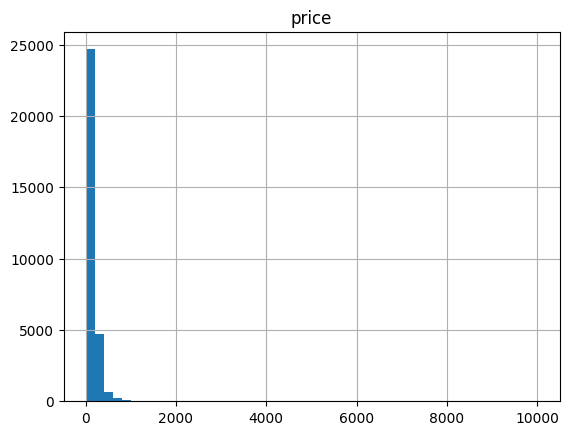

df.shape: (12925, 13) 

[nan 'No' 'Yes'] 

subject_injury
Yes    1631
No     1446
Name: count, dtype: int64 

Total missings: 9848
proportion missing: 0.762 

force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    150  
Yes                         44    172   

force_type  Baton  Bodily Force  Chemical Irritant  Firearm  \
injury_nan                

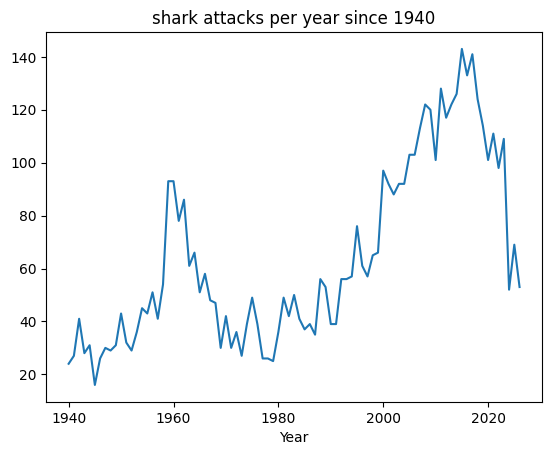

Year
1940     283
1950     467
1960     618
1970     339
1980     438
1990     572
2000    1022
2010    1249
2020     593
Name: count, dtype: int64 

Age
16    92
19    90
17    89
17    87
18    85
15    84
20    79
20    77
18    75
15    73
21    72
25    70
22    67
14    63
19    63
16    61
22    60
21    59
24    59
24    58
26    57
13    57
14    56
12    55
13    52
Name: count, dtype: int64 

Total missings: 3122 ( 0.439 )
count    3995.000000
mean       28.281101
std        14.702400
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64 



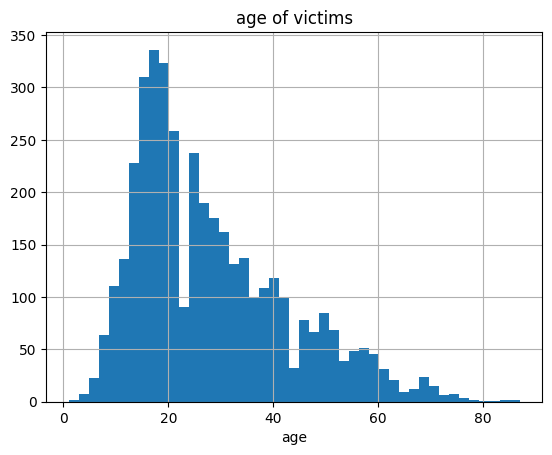

Sex
M        5704
F         816
M           7
?           2
F           2
N           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64 

Sex
M    5713
F     818
Name: count, dtype: int64 

Total missings: 586 

male: 5713 sex recorded: 6531
proportion male: 0.875 

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64 

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

proportion unprovoked: 0.739
proportion unprovoked, classified only: 0.89 



In [3]:
# Your Phase 2 solution to the problem goes here.
# ds3001 data wrangling hw
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# ---------- Q1.1 airbnb price ----------
df = pd.read_csv('./data/airbnb_hw.csv', low_memory=False)
print('df.shape:', df.shape, '\n')

var = 'Price'
print(df[var].dtype)
print(df[var].unique()[0:15], '\n')

# it's object not a number. looks like anything over 999 has a comma in it
# (1,990 / 5,000) so pandas can't read the column as numeric. take the comma
# out first like we did with the $ sign, then coerce.
df[var] = df[var].str.replace(',', '')
df[var] = pd.to_numeric(df[var], errors='coerce')
df['price_nan'] = df[var].isnull()

print('Total missings:', sum(df['price_nan']), '\n')
print(df[var].describe(), '\n')

df[var].hist(bins=50)
plt.title('price')
plt.show()

# Q1.1 answer: 0 missing. everything converts once the comma is gone.
# range is 10 to 10000, median 125, mean 164, so it's skewed right.
# i didn't fill or drop anything, price is a measured value and making
# some up would be a different kind of decision.


# ---------- Q1.2 mn police subject_injury ----------
df = pd.read_csv('./data/mn_police_use_of_force.csv', low_memory=False)
print('df.shape:', df.shape, '\n')

var = 'subject_injury'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

# only Yes / No / blank in here, no weird codes like y or 1 to fix. so the
# real question is the NAs. leaving them as nan and keeping a flag, same as
# age_nan in the lecture. could recode them to No but that assumes officers
# only wrote it down when there was an injury, and nothing in the file says
# that.
df[var] = df[var].str.strip()
df[var] = df[var].replace(['', ' '], np.nan)
df['injury_nan'] = df[var].isnull()

print('Total missings:', sum(df['injury_nan']))
print('proportion missing:', df['injury_nan'].mean().round(3), '\n')

# the crosstab the question asks for
print(pd.crosstab(df[var], df['force_type']), '\n')

# and where the missing ones are
ct = pd.crosstab(df['injury_nan'], df['force_type'])
print(ct, '\n')
print('share missing by force type:')
print((ct.loc[True] / ct.sum()).round(3), '\n')

# two whole categories are 100% missing which seems weird, so checking if
# it's a time thing. year is just the first 4 characters of the timestamp.
df['year'] = df['response_datetime'].str[0:4]
print(pd.crosstab(df['injury_nan'], df['year']), '\n')

df['day'] = df['response_datetime'].str[0:10]
print('last record with a value:', df.loc[df['injury_nan'] == False, 'day'].max(), '\n')

df['old'] = df['day'] <= '2018/06/02'
print('rows up to then:', sum(df['old']),
      'missing:', df.loc[df['old'], 'injury_nan'].mean().round(3))
print('rows after:     ', sum(~df['old']),
      'missing:', df.loc[~df['old'], 'injury_nan'].mean().round(3), '\n')

ct2 = pd.crosstab(df.loc[df['old'], 'injury_nan'],
                  df.loc[df['old'], 'force_type'])
print(ct2, '\n')
print('share missing by force type, earlier period only:')
print((ct2.loc[True] / ct2.sum()).round(3), '\n')

# Q1.2 answer: 9848 of 12925 missing = 76.2%. yes it's a concern.
#
# only 3077 incidents have any injury value at all so anything you compute
# on the complete cases uses less than a quarter of the data. and the
# missing ones don't look like the ones we can see.
#
# the crosstab by year shows why. 2016 and 2017 are around 35-40% missing
# but 2019 2020 2021 are all exactly 1.00. the last record with any value
# is 2018/06/02, so after that the field just stopped being filled in.
# that's 7982 rows and about 81% of all the missing values. it also
# explains why Maximal Restraint Technique and Less Lethal were 100%
# missing, those categories only show up after the cutoff.
#
# in the earlier period it's still 38% missing and it depends on the force
# type. chemical irritant is 82% missing and when it does get recorded the
# answer is mostly No (131 No vs 41 Yes). taser is 5% missing and k9 bite
# is 0%, and both of those have high injury rates. bodily force is in the
# middle at 30%. pepper spray doesn't leave a mark so there's nothing to
# write down, a dog bite does.
#
# so injuries get recorded when you can see them, which means the missing
# ones are probably mostly non-injuries and the 53% injury rate you get
# from the complete cases is too high.

df.to_csv('mn_police_clean.csv', index=False)


# ---------- Q2.1 open the shark file ----------
# .xls is old excel so read_csv won't work, need read_excel.
df = pd.read_excel('./data/GSAF5.xls')
print('df.shape:', df.shape, '\n')
print(df.dtypes, '\n')
df.head()


# ---------- Q2.2 drop empty columns ----------
print(df.notnull().sum().sort_values(), '\n')

# Unnamed 21 and 22 have 1 and 2 values in them and that's it
print(df[['Unnamed: 21', 'Unnamed: 22']].dropna(how='all'), '\n')
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
df = df.rename(columns={'Species ': 'Species'})
print('df.shape:', df.shape, '\n')


# ---------- Q2.3 year ----------
var = 'Year'
print(df[var].describe(), '\n')
print(df.loc[df[var] < 1900, var].value_counts().sort_index().head(), '\n')
print(df.loc[df[var] == 0, ['Date', 'Year', 'Country']].tail(), '\n')
print(df.loc[(df[var] > 0) & (df[var] < 1500), ['Date', var, 'Country']], '\n')

# range is 0 to 2026. there are 129 rows with 0 and 0 isn't a year, their
# Date column says things like "1845-1853" or "Before 1906" so 0 is being
# used for "don't know", same idea as the 9 and 99 codes in the pretrial
# data. recoding to nan. the 5 / 77 / 1000 ones are real entries though,
# their Date fields say "Ca. 5 A.D." and so on, so i'm leaving them, and
# they drop out at the 1940 filter anyway.
df[var] = df[var].replace(0, np.nan)
df['year_nan'] = df[var].isnull()
print('Total missings:', sum(df['year_nan']))
print('range now:', df[var].min(), 'to', df[var].max(), '\n')

recent = df[df[var] >= 1940]
print('records since 1940:', recent.shape[0], '\n')

recent[var].value_counts().sort_index().plot()
plt.title('shark attacks per year since 1940')
plt.show()

decade = (recent[var] // 10 * 10).astype(int)
print(decade.value_counts().sort_index(), '\n')

# Q2.3 answer: increasing overall, 283 in the 1940s up to 1249 in the 2010s.
# not a steady climb though, the 1970s drops back to 339 before picking up
# again. the 2020s number is lower but that decade isn't finished yet so you
# can't compare it directly. the last couple of years in the plot drop off a
# lot which is probably just because recent cases haven't been verified yet.
#
# but this is counting recorded attacks, not the actual risk. way more
# people surf and swim now than in 1940 and reporting is much better, so
# some of the increase is that and not sharks.


# ---------- Q2.4 age ----------
var = 'Age'
print(df[var].value_counts().head(25), '\n')

# object because of stuff like 30s, 20's, 30+, 40?, Teen, ?, 28 & 22,
# 18 months. taking off the s, the apostrophe, the + and the ? gets the
# ones that have a real number with something stuck on it, and coerce
# turns the rest into nan. i'm reading '30s' as 30 rather than 35, since
# 30 is actually in the cell and 35 would be me making up a number. the
# ones with two ages in them like '28 & 22' are really two victims in one
# row so i'm not trying to guess which one to keep.
a = df[var].astype(str).str.strip()
a = a.str.replace("'", '').str.replace('s', '')
a = a.str.replace('+', '', regex=False).str.replace('?', '', regex=False)
df[var] = pd.to_numeric(a, errors='coerce')
df.loc[df[var] > 110, var] = np.nan
df['age_nan'] = df[var].isnull()

print('Total missings:', sum(df['age_nan']),
      '(', df['age_nan'].mean().round(3), ')')
print(df[var].describe(), '\n')

df[var].hist(bins=45)
plt.title('age of victims')
plt.xlabel('age')
plt.show()

# Q2.4 answer: skewed right, peaks around the late teens. median 24 mean 28
# with a small tail past 60. probably just who's in the water for hours at
# a time. age is missing for 43.9% of rows though so this is only
# describing the ones that got written down.


# ---------- Q2.5 proportion male ----------
var = 'Sex'
print(df[var].value_counts(), '\n')

# extra spaces, lowercase m, and some junk values. dropping the junk.
df[var] = df[var].str.strip().str.upper()
df[var] = df[var].replace(['?', '.', 'N', 'LLI', 'M F', 'M X 2'], np.nan)
df['sex_nan'] = df[var].isnull()

print(df[var].value_counts(), '\n')
print('Total missings:', sum(df['sex_nan']), '\n')

male = sum(df[var] == 'M')
known = sum(df['sex_nan'] == False)
print('male:', male, 'sex recorded:', known)
print('proportion male:', round(male / known, 3), '\n')

# Q2.5 answer: 87.5% male, out of the 6531 rows where sex is recorded.
# 586 rows don't have it. even if every single one of those was female
# it'd still be 80% so the answer doesn't really change.


# ---------- Q2.6 type ----------
var = 'Type'
print(df[var].value_counts(), '\n')

# UNprovoked / unprovoked / ' Provoked' are just capitalization and spacing
# so .title() fixes those. Invalid, Questionable, Unconfirmed etc are
# non-answers so they go to Unknown. Watercraft and Sea Disaster and Boat
# are a different kind of event and there's no third real category to put
# them in, and we don't actually know if the shark was provoked, so Unknown.
df[var] = df[var].str.strip().str.title()
df[var] = df[var].replace(['Invalid', 'Watercraft', 'Sea Disaster', 'Boat',
                           'Questionable', 'Unconfirmed', 'Unverified',
                           'Under Investigation', '?'], 'Unknown')
df[var] = df[var].fillna('Unknown')
print(df[var].value_counts(), '\n')

unprovoked = sum(df[var] == 'Unprovoked')
print('proportion unprovoked:', round(unprovoked / df.shape[0], 3))
classified = sum(df[var] != 'Unknown')
print('proportion unprovoked, classified only:', round(unprovoked / classified, 3), '\n')

# Q2.6 answer: 73.9% of all rows are unprovoked. if you only count the rows
# that actually got classified it's 89%, but the 1205 Unknowns are mostly
# boat strikes and invalid reports which wouldn't have been unprovoked
# anyway, so 73.9% is the one i'd report.

df.to_csv('shark_attacks_clean.csv', index=False)

### *Reflection on AI assistance
In your own words without generative AI.


The one substantive change was in Age. Phase 1 stripped the apostrophe and the trailing 's' but left '+' and '?', so values like '30+' and '40?' were coerced to NaN even though a usable number was sitting right there. Fixing it recovered 7 rows. What surprised me was how little it mattered: the median stayed at 24 and the mean moved from 28.26 to 28.28. A real bug and an immaterial one at the same time. The other two changes were smaller — printing the non-zero implausible years before recoding, and computing the 89% figure the comment had been claiming without an output behind it.

The AI I used made mistakes I had to catch. At one point it changed the police date cutoff from a specific day to the whole month, which quietly threw off numbers I had already written down. A follow-up review said two case number columns disagreed on 369 rows, but 319 of those were blank in both and only one had a value on a single side, so the real count of rows where both columns held different values was 49. I took 3 of its 8 suggestions.

To check the work I made the numbers add up against each other. Removing the comma left zero missings, which means every value converted. The year table's counts came to 3077, the same as Yes plus No. The Sex and decade counts also reconciled.

Still not sure about: Age mixes numbers and text so value_counts() lists some ages twice, and the 1970s dip means "increasing" is a general trend, not every decade.